# NLP & representation learning: Neural Embeddings, Text Classification


To use statistical classifiers with text, it is first necessary to vectorize the text. In the first practical session we explored the **Bag of Word (BoW)** model.

Modern **state of the art** methods uses  embeddings to vectorize the text before classification in order to avoid feature engineering.

## [Dataset](https://thome.isir.upmc.fr/classes/RITAL/json_pol.json)


## "Modern" NLP pipeline

By opposition to the **bag of word** model, in the modern NLP pipeline everything is **embeddings**. Instead of encoding a text as a **sparse vector** of length $D$ (size of feature dictionnary) the goal is to encode the text in a meaningful dense vector of a small size $|e| <<< |D|$.


The raw classification pipeline is then the following:

```
raw text ---|embedding table|-->  vectors --|Neural Net|--> class
```


### Using a  language model:

How to tokenize the text and extract a feature dictionnary is still a manual task. To directly have meaningful embeddings, it is common to use a pre-trained language model such as `word2vec` which we explore in this practical.

In this setting, the pipeline becomes the following:
```
      
raw text ---|(pre-trained) Language Model|--> vectors --|classifier (or fine-tuning)|--> class
```


- #### Classic word embeddings

 - [Word2Vec](https://arxiv.org/abs/1301.3781)
 - [Glove](https://nlp.stanford.edu/projects/glove/)


- #### bleeding edge language models techniques (see next)

 - [UMLFIT](https://arxiv.org/abs/1801.06146)
 - [ELMO](https://arxiv.org/abs/1802.05365)
 - [GPT](https://blog.openai.com/language-unsupervised/)
 - [BERT](https://arxiv.org/abs/1810.04805)






### Goal of this session:

1. Train word embeddings on training dataset
2. Tinker with the learnt embeddings and see learnt relations
3. Tinker with pre-trained embeddings.
4. Use those embeddings for classification
5. Compare different embedding models

## STEP 0: Loading data

In [1]:
!wget -O json_pol.json https://thome.isir.upmc.fr/classes/RITAL/json_pol.json

--2026-03-29 23:46:55--  https://thome.isir.upmc.fr/classes/RITAL/json_pol.json
Resolving thome.isir.upmc.fr (thome.isir.upmc.fr)... 134.157.18.247
Connecting to thome.isir.upmc.fr (thome.isir.upmc.fr)|134.157.18.247|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 32663547 (31M) [application/json]
Saving to: ‘json_pol.json’

json_pol.json       100%[===================>]  31.15M  18.5MB/s    in 1.7s    

2026-03-29 23:46:57 (18.5 MB/s) - ‘json_pol.json’ saved [32663547/32663547]



In [2]:
import json
from collections import Counter

# Loading json
file = './datasets/json_pol.json'
with open(file,encoding="utf-8") as f:
    data = json.load(f)


# Quick Check
counter = Counter((x[1] for x in data))
print("Number of reviews : ", len(data))
print("----> # of positive : ", counter[1])
print("----> # of negative : ", counter[0])
print("")
print(data[0])

Number of reviews :  25000
----> # of positive :  12500
----> # of negative :  12500

['Although credit should have been given to Dr. Seuess for stealing the story-line of "Horton Hatches The Egg", this was a fine film. It touched both the emotions and the intellect. Due especially to the incredible performance of seven year old Justin Henry and a script that was sympathetic to each character (and each one\'s predicament), the thought provoking elements linger long after the tear jerking ones are over. Overall, superior acting from a solid cast, excellent directing, and a very powerful script. The right touches of humor throughout help keep a "heavy" subject from becoming tedious or difficult to sit through. Lastly, this film stands the test of time and seems in no way dated, decades after it was released.', 1]


In [3]:
data

[['Although credit should have been given to Dr. Seuess for stealing the story-line of "Horton Hatches The Egg", this was a fine film. It touched both the emotions and the intellect. Due especially to the incredible performance of seven year old Justin Henry and a script that was sympathetic to each character (and each one\'s predicament), the thought provoking elements linger long after the tear jerking ones are over. Overall, superior acting from a solid cast, excellent directing, and a very powerful script. The right touches of humor throughout help keep a "heavy" subject from becoming tedious or difficult to sit through. Lastly, this film stands the test of time and seems in no way dated, decades after it was released.',
  1],
 ["This was one of those films I would always come across (be it on TV or cheap DVD), but never struck me to give it a shot as I thought I wasn't missing out on much. It was on one night and I thought oh well\x85 why not. A good decision too, as I would kick 

## Word2Vec: Quick Recap

**[Word2Vec](https://arxiv.org/abs/1301.3781) is composed of two distinct language models (CBOW and SG), optimized to quickly learn word vectors**


given a random text: `i'm taking the dog out for a walk`



### (a) Continuous Bag of Word (CBOW)
    -  predicts a word given a context
    
maximizing `p(dog | i'm taking the ___ out for a walk)`
    
### (b) Skip-Gram (SG)               
    -  predicts a context given a word
    
 maximizing `p(i'm taking the out for a walk | dog)`



   

## STEP 1: train a language model (word2vec)

Gensim has one of [Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html) fastest implementation.


### Train:

In [4]:
# if gensim not installed yet
# ! pip install gensim

In [5]:
import gensim
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

text = [t.split() for t,p in data]

# the following configuration is the default configuration
w2v = gensim.models.word2vec.Word2Vec(sentences=text,
                                vector_size=100, window=5,               ### here we train a cbow model
                                min_count=5,
                                sample=0.001, workers=3,
                                sg=1, hs=0, negative=5,        ### set sg to 1 to train a sg model
                                cbow_mean=1, epochs=5)

2026-03-29 23:46:58,780 : INFO : collecting all words and their counts
2026-03-29 23:46:58,780 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-29 23:46:59,168 : INFO : PROGRESS: at sentence #10000, processed 2301366 words, keeping 153853 word types
2026-03-29 23:46:59,681 : INFO : PROGRESS: at sentence #20000, processed 4553558 words, keeping 240043 word types
2026-03-29 23:46:59,930 : INFO : collected 276678 word types from a corpus of 5713167 raw words and 25000 sentences
2026-03-29 23:46:59,931 : INFO : Creating a fresh vocabulary
2026-03-29 23:47:00,117 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 48208 unique words (17.42% of original 276678, drops 228470)', 'datetime': '2026-03-29T23:47:00.117020', 'gensim': '4.4.0', 'python': '3.13.7 (main, Sep 18 2025, 22:52:34) [Clang 20.1.4 ]', 'platform': 'macOS-26.3.1-arm64-arm-64bit-Mach-O', 'event': 'prepare_vocab'}
2026-03-29 23:47:00,117 : INFO : Word2Vec lifecycle event {'m

In [6]:
# Worth it to save the previous embedding
w2v.save("W2v-movies.dat")
# You will be able to reload them:
# w2v = gensim.models.Word2Vec.load("W2v-movies.dat")
# and you can continue the learning process if needed

2026-03-29 23:48:03,503 : INFO : Word2Vec lifecycle event {'fname_or_handle': 'W2v-movies.dat', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2026-03-29T23:48:03.503517', 'gensim': '4.4.0', 'python': '3.13.7 (main, Sep 18 2025, 22:52:34) [Clang 20.1.4 ]', 'platform': 'macOS-26.3.1-arm64-arm-64bit-Mach-O', 'event': 'saving'}
2026-03-29 23:48:03,507 : INFO : not storing attribute cum_table
2026-03-29 23:48:03,534 : INFO : saved W2v-movies.dat


In [7]:
# Gensim 4.x
vocab_words = list(w2v.wv.key_to_index.keys())   # all words
print(len(vocab_words))
print(vocab_words[:20])

48208
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'I', 'that', 'this', 'it', '/><br', 'was', 'with', 'as', 'for', 'The', 'but', 'on', 'movie']


In [8]:
vocab_words_sorted = sorted(w2v.wv.key_to_index)

In [9]:
vocab_words

['the',
 'a',
 'and',
 'of',
 'to',
 'is',
 'in',
 'I',
 'that',
 'this',
 'it',
 '/><br',
 'was',
 'with',
 'as',
 'for',
 'The',
 'but',
 'on',
 'movie',
 'are',
 'have',
 'film',
 'his',
 'not',
 'you',
 'be',
 'at',
 'by',
 'one',
 'an',
 'he',
 'from',
 'who',
 'like',
 'they',
 'all',
 'so',
 'just',
 'or',
 'has',
 'about',
 'out',
 'her',
 'some',
 'very',
 'more',
 'This',
 'would',
 'what',
 'when',
 'good',
 'if',
 'their',
 'only',
 'up',
 'It',
 'really',
 'had',
 'even',
 'can',
 "it's",
 'see',
 'my',
 'were',
 'which',
 'no',
 'than',
 'there',
 'she',
 '-',
 'been',
 'into',
 'get',
 'will',
 'much',
 'because',
 'story',
 'other',
 'most',
 'me',
 'time',
 'we',
 'make',
 'do',
 'how',
 'could',
 'great',
 'also',
 '/>The',
 'people',
 'its',
 'any',
 "don't",
 'first',
 'made',
 'think',
 'bad',
 '<br',
 'him',
 'many',
 'being',
 'never',
 'then',
 'two',
 'where',
 'it.',
 'But',
 'too',
 'your',
 'after',
 'them',
 'And',
 'way',
 'little',
 'know',
 'movie.',
 'w

In [10]:
vocab_words_sorted

['!',
 '!!',
 '!!!',
 '!!!!',
 '!!!!!',
 '!!!!<br',
 '!!<br',
 '!"',
 '!)',
 '!<br',
 '"',
 '".',
 '"...',
 '".<br',
 '"0"',
 '"1"',
 '"10',
 '"10"',
 '"101',
 '"12',
 '"15',
 '"2"',
 '"2001:',
 '"24"',
 '"50',
 '"8',
 '"9',
 '"A',
 '"A"',
 '"Abbott',
 '"Aeon',
 '"After',
 '"Air',
 '"Airport"',
 '"Alice',
 '"Alice"',
 '"Alien',
 '"Alien"',
 '"All',
 '"Alone',
 '"Am',
 '"American',
 '"An',
 '"And',
 '"Angel',
 '"Angels',
 '"Animal',
 '"Anna',
 '"Any',
 '"Anywhere',
 '"Apocalypse',
 '"Are',
 '"Armageddon"',
 '"Arrested',
 '"As',
 '"Assault',
 '"Asterix',
 '"Astérix',
 '"At',
 '"Attack',
 '"Au',
 '"Austin',
 '"Autumn',
 '"B',
 '"B"',
 '"Babette\'s',
 '"Baby',
 '"Back',
 '"Bad',
 '"Batman',
 '"Batman"',
 '"Battle',
 '"Battlefield',
 '"Be',
 '"Beast',
 '"Beautiful',
 '"Because',
 '"Before',
 '"Begotten"',
 '"Being',
 '"Benji"',
 '"Best',
 '"Better',
 '"Beyond',
 '"Big',
 '"Billy',
 '"Black',
 '"Blade',
 '"Blair',
 '"Blind',
 '"Blood',
 '"Bloody',
 '"Blue',
 '"Body',
 '"Bon',
 '"Boogie',
 '"

In [11]:
w2v.wv[0]

array([-0.06262495,  0.03246766,  0.05622495,  0.00995871, -0.16061287,
       -0.4536986 ,  0.18748441,  0.06890783, -0.2192545 , -0.05310215,
        0.3788647 , -0.4762275 , -0.13605481,  0.06939923,  0.10270845,
       -0.35779047,  0.19195358, -0.06818616, -0.4262786 , -0.5154329 ,
        0.32363132, -0.20867223,  0.5157631 , -0.17095388,  0.18106112,
       -0.01394317,  0.04086094,  0.19086756, -0.30053297, -0.03181499,
        0.06566186, -0.05881853,  0.19710688, -0.11412218,  0.05361814,
       -0.12824011,  0.23560008, -0.21087837, -0.22926868, -0.41226235,
       -0.13051085, -0.09413809, -0.14888875,  0.01558455,  0.09252451,
        0.10275356, -0.40003464,  0.37258294,  0.19054615,  0.11994404,
       -0.10701801, -0.20591432,  0.02644187, -0.18676446,  0.04638337,
       -0.44752678,  0.209556  ,  0.01435463, -0.3144836 ,  0.26002932,
        0.10200822, -0.09863923,  0.22204414,  0.26122785, -0.1729295 ,
        0.154323  ,  0.05866688,  0.03036606, -0.11096766,  0.19

## STEP 2: Test learnt embeddings

The word embedding space directly encodes similarities between words: the vector coding for the word "great" will be closer to the vector coding for "good" than to the one coding for "bad". Generally, [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) is the distance used when considering distance between vectors.

KeyedVectors have a built in [similarity](https://radimrehurek.com/gensim/models /keyedvectors.html#gensim.models.keyedvectors.BaseKeyedVectors.similarity) method to compute the cosine similarity between words

In [12]:
# is great really closer to good than to bad ?
print("great and good:",w2v.wv.similarity("great","good"))
print("great and bad:",w2v.wv.similarity("great","bad"))

great and good: 0.77903616
great and bad: 0.46456033


Since cosine distance encodes similarity, neighboring words are supposed to be similar. The [most_similar](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.BaseKeyedVectors.most_similar) method returns the `topn` words given a query.

In [13]:
# The query can be as simple as a word, such as "movie"

# Try changing the word
w2v.wv.most_similar("movie",topn=5) # 5 most similar words
#w2v.wv.most_similar("awesome",topn=5)
#w2v.wv.most_similar("actor",topn=5)

[('film', 0.9330549836158752),
 ('"movie"', 0.8049684166908264),
 ('flick', 0.791227400302887),
 ('movie,', 0.7615038156509399),
 ('stinker', 0.734287440776825)]

In [14]:
w2v.wv.most_similar("Hollywood",topn=5)

[('mainstream', 0.7650157809257507),
 ('Bollywood', 0.707881510257721),
 ('hollywood', 0.6990286111831665),
 ('direct-to-video', 0.6951810717582703),
 ('indie', 0.6913636922836304)]

But it can be a more complicated query
Word embedding spaces tend to encode much more.

The most famous exemple is: `vec(king) - vec(man) + vec(woman) => vec(queen)`

In [15]:
# What is awesome - good + bad ?
w2v.wv.most_similar(positive=["awesome","bad"],negative=["good"],topn=3)

#w2v.wv.most_similar(positive=["actor","woman"],negative=["man"],topn=3) # do the famous exemple works for actor ?


# Try other things like plurals for exemple.

[('awful', 0.7648922801017761),
 ('terrible', 0.6642677783966064),
 ('horrible', 0.6606865525245667)]

**To test learnt "synctactic" and "semantic" similarities, Mikolov et al. introduced a special dataset containing a wide variety of three way similarities.**

**You can download the dataset [here](https://thome.isir.upmc.fr/classes/RITAL/questions-words.txt).**

In [16]:
!wget -O questions-words.txt https://thome.isir.upmc.fr/classes/RITAL/questions-words.txt

--2026-03-29 23:48:03--  https://thome.isir.upmc.fr/classes/RITAL/questions-words.txt
Resolving thome.isir.upmc.fr (thome.isir.upmc.fr)... 134.157.18.247
Connecting to thome.isir.upmc.fr (thome.isir.upmc.fr)|134.157.18.247|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 603955 (590K) [text/plain]
Saving to: ‘questions-words.txt’

questions-words.txt 100%[===================>] 589.80K  --.-KB/s    in 0.07s   

2026-03-29 23:48:04 (8.48 MB/s) - ‘questions-words.txt’ saved [603955/603955]



In [17]:
out = w2v.wv.evaluate_word_analogies("datasets/questions-words.txt",case_insensitive=True)  #original semantic syntactic dataset.

2026-03-29 23:48:04,259 : INFO : Evaluating word analogies for top 300000 words in the model on datasets/questions-words.txt
2026-03-29 23:48:04,399 : INFO : capital-common-countries: 3.3% (3/90)
2026-03-29 23:48:04,514 : INFO : capital-world: 0.0% (0/71)
2026-03-29 23:48:04,544 : INFO : currency: 0.0% (0/28)
2026-03-29 23:48:04,894 : INFO : city-in-state: 0.0% (0/329)
2026-03-29 23:48:05,311 : INFO : family: 39.2% (134/342)
2026-03-29 23:48:06,346 : INFO : gram1-adjective-to-adverb: 1.6% (15/930)
2026-03-29 23:48:06,926 : INFO : gram2-opposite: 2.5% (14/552)
2026-03-29 23:48:08,268 : INFO : gram3-comparative: 21.1% (266/1260)
2026-03-29 23:48:09,051 : INFO : gram4-superlative: 6.1% (43/702)
2026-03-29 23:48:09,809 : INFO : gram5-present-participle: 16.1% (122/756)
2026-03-29 23:48:10,622 : INFO : gram6-nationality-adjective: 1.6% (13/792)
2026-03-29 23:48:11,982 : INFO : gram7-past-tense: 16.5% (208/1260)
2026-03-29 23:48:12,852 : INFO : gram8-plural: 6.7% (54/812)
2026-03-29 23:48:13

**When training the w2v models on the review dataset, since it hasn't been learnt with a lot of data, it does not perform very well.**


## Word2vec visualisation

2026-03-29 23:48:14,320 : INFO : NumExpr defaulting to 10 threads.


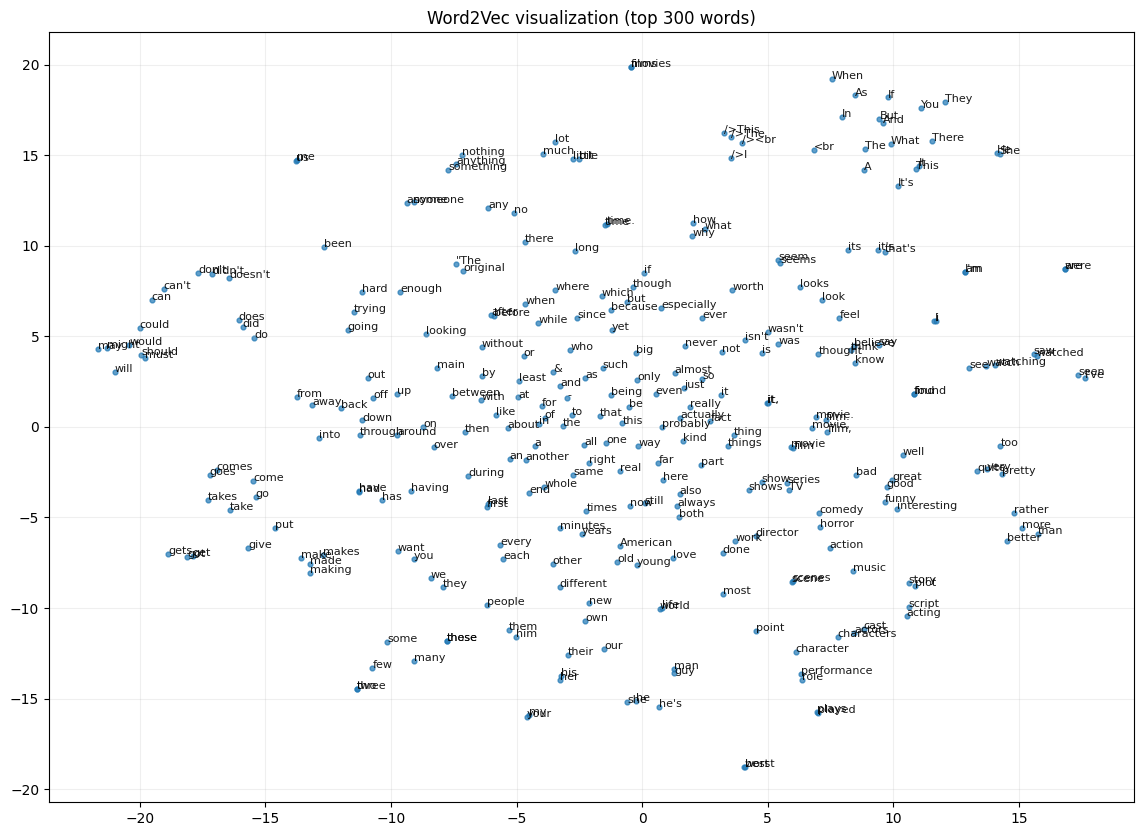

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Number of words to display (most frequent in the model vocab)
n_words = 300
words = w2v.wv.index_to_key[:n_words]
X = np.array([w2v.wv[w] for w in words])

# Optional speed-up: reduce to 50D before t-SNE
X_50 = PCA(n_components=min(50, X.shape[1]), random_state=42).fit_transform(X)

# 2D projection
X_2d = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca",
    learning_rate="auto"
).fit_transform(X_50)

# Plot
plt.figure(figsize=(14, 10))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=12, alpha=0.7)

for i, w in enumerate(words):
    plt.annotate(w, (X_2d[i, 0], X_2d[i, 1]), fontsize=8, alpha=0.9)

plt.title(f"Word2Vec visualization (top {n_words} words)")
plt.grid(alpha=0.2)
plt.show()

In [19]:
d = 17  # dimension to inspect
words = w2v.wv.index_to_key
M = w2v.wv.vectors  # shape: (vocab_size, dim)

vals = M[:, d]
top_idx = np.argsort(vals)[-20:][::-1]
bot_idx = np.argsort(vals)[:20]

print("High end:")
print([words[i] for i in top_idx])

print("\nLow end:")
print([words[i] for i in bot_idx])

High end:
['cover', 'everyone', 'thin', 'forward', 'reviews', 'walk', 'guessing', 'through', 'everybody', 'wanted', 'through.', 'laughing', 'them.', 'sit', 'anybody', 'looking', 'flat', 'amazed', 'scenery', 'felt']

Low end:
['(Brazil):', 'THE', '/>Title', 'opinion,', 'sequence', 'favorite', 'OF', 'word', 'IN', '(as', 'year', 'Award', 'considered', '(', 'favourite', 'worst', '(played', 'raised', 'question', 'returns']


In [20]:
# example: sentiment scores per word (if you have a lexicon dict: sent[word] -> score)
common = [w for w in words if w in top_idx]
x = np.array([w2v.wv[w][d] for w in common])
y = np.array([sent[w] for w in common])

corr = np.corrcoef(x, y)[0,1]
print(corr)

nan


/Users/glouno/Documents/Sorbonne/RITAL/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
/Users/glouno/Documents/Sorbonne/RITAL/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/glouno/Documents/Sorbonne/RITAL/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/glouno/Documents/Sorbonne/RITAL/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/glouno/Documents/Sorbonne/RITAL/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


## STEP 3: Loading a pre-trained model

In Gensim, embeddings are loaded and can be used via the ["KeyedVectors"](https://radimrehurek.com/gensim/models/keyedvectors.html) class

> Since trained word vectors are independent from the way they were trained (Word2Vec, FastText, WordRank, VarEmbed etc), they can be represented by a standalone structure, as implemented in this module.

>The structure is called “KeyedVectors” and is essentially a mapping between entities and vectors. Each entity is identified by its string id, so this is a mapping between {str => 1D numpy array}.

>The entity typically corresponds to a word (so the mapping maps words to 1D vectors), but for some models, they key can also correspond to a document, a graph node etc. To generalize over different use-cases, this module calls the keys entities. Each entity is always represented by its string id, no matter whether the entity is a word, a document or a graph node.

**You can download the pre-trained word embedding [HERE](https://thome.isir.upmc.fr/classes/RITAL/word2vec-google-news-300.dat) .**

In [21]:
#from gensim.test.utils import get_tmpfile
import gensim.downloader as api
from gensim.models import KeyedVectors

bload = True
fname = "word2vec-google-news-300"
sdir = "" # Change

if(bload==True):
    wv_pre_trained = KeyedVectors.load(sdir+fname+".dat")
else:
    wv_pre_trained = api.load(fname)
    wv_pre_trained.save(sdir+fname+".dat")

2026-03-29 23:48:17,921 : INFO : loading KeyedVectors object from word2vec-google-news-300.dat
2026-03-29 23:48:19,236 : INFO : loading vectors from word2vec-google-news-300.dat.vectors.npy with mmap=None
2026-03-29 23:48:21,632 : INFO : KeyedVectors lifecycle event {'fname': 'word2vec-google-news-300.dat', 'datetime': '2026-03-29T23:48:21.630023', 'gensim': '4.4.0', 'python': '3.13.7 (main, Sep 18 2025, 22:52:34) [Clang 20.1.4 ]', 'platform': 'macOS-26.3.1-arm64-arm-64bit-Mach-O', 'event': 'loaded'}


**Perform the "synctactic" and "semantic" evaluations again. Conclude on the pre-trained embeddings.**

In [22]:
out = wv_pre_trained.evaluate_word_analogies("datasets/questions-words.txt",case_insensitive=True)  #original semantic syntactic dataset.

2026-03-29 23:48:21,974 : INFO : Evaluating word analogies for top 300000 words in the model on datasets/questions-words.txt
2026-03-29 23:48:41,080 : INFO : capital-common-countries: 83.2% (421/506)
2026-03-29 23:50:22,292 : INFO : capital-world: 81.3% (3552/4368)
2026-03-29 23:50:38,725 : INFO : currency: 28.5% (230/808)
2026-03-29 23:51:31,589 : INFO : city-in-state: 72.1% (1779/2467)
2026-03-29 23:51:42,694 : INFO : family: 86.2% (436/506)
2026-03-29 23:52:04,669 : INFO : gram1-adjective-to-adverb: 29.2% (290/992)
2026-03-29 23:52:20,870 : INFO : gram2-opposite: 43.5% (353/812)
2026-03-29 23:52:46,771 : INFO : gram3-comparative: 91.3% (1216/1332)
2026-03-29 23:53:08,659 : INFO : gram4-superlative: 88.0% (987/1122)
2026-03-29 23:53:29,123 : INFO : gram5-present-participle: 78.5% (829/1056)
2026-03-29 23:54:02,115 : INFO : gram6-nationality-adjective: 90.2% (1442/1599)
2026-03-29 23:54:33,875 : INFO : gram7-past-tense: 65.4% (1020/1560)
2026-03-29 23:55:02,583 : INFO : gram8-plural: 

## STEP 4:  sentiment classification

In the previous practical session, we used a bag of word approach to transform text into vectors.
Here, we propose to try to use word vectors (previously learnt or loaded).


### <font color='green'> Since we have only word vectors and that sentences are made of multiple words, we need to aggregate them. </font>


### (1) Vectorize reviews using word vectors:

Word aggregation can be done in different ways:

- Sum
- Average
- Min/feature
- Max/feature

#### a few pointers:

- `w2v.wv.vocab` is a `set()` of the vocabulary (all existing words in your model)
- `np.minimum(a,b) and np.maximum(a,b)` respectively return element-wise min/max

In [23]:
import numpy as np
from sklearn.model_selection import train_test_split

# We first need a train/test split before vectorization
labels = [pol for text, pol in data]
train, test = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=labels,
)

# We first need to vectorize text:
# First we propose to a sum of them
def vectorize(text, keyed_vectors=None, mean=False):
    """
    Vectorize one review by aggregating token embeddings.

    input: str
    output: np.array(float)
    """
    if keyed_vectors is None:
        keyed_vectors = w2v.wv

    tokens = text.split()
    vectors = [keyed_vectors[word] for word in tokens if word in keyed_vectors]

    if not vectors:
        return np.zeros(keyed_vectors.vector_size, dtype=np.float32)

    mat = np.vstack(vectors)
    return mat.mean(axis=0) if mean else mat.sum(axis=0)


classes = [pol for text, pol in train]
X = np.vstack([vectorize(text) for text, pol in train])
X_test = np.vstack([vectorize(text) for text, pol in test])
true = [pol for text, pol in test]

# let's see what a review vector looks like.
print(X[0][:10])
print("train shape:", X.shape, "test shape:", X_test.shape)

[  7.03357   25.69501   11.963356  -6.770841  -9.387801 -34.21765
  12.985076  56.70608  -32.672897 -30.365328]
train shape: (20000, 100) test shape: (5000, 100)


### (2) Train a classifier
as in the previous practical session, train a logistic regression to do sentiment classification with word vectors



In [24]:
from pathlib import Path
import codecs
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


def run_logreg(train_set, test_set, keyed_vectors, mean=False):
    X_train = np.vstack([vectorize(text, keyed_vectors, mean=mean) for text, _ in train_set])
    y_train = np.array([label for _, label in train_set])
    X_eval = np.vstack([vectorize(text, keyed_vectors, mean=mean) for text, _ in test_set])
    y_eval = np.array([label for _, label in test_set])

    clf = LogisticRegression(max_iter=2000, random_state=42)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_eval)

    print(f"accuracy = {accuracy_score(y_eval, pred):.4f}")
    print(classification_report(y_eval, pred, digits=4))


print("=== Movie review sentiment (sum pooling) ===")
review_tokens = [text.split() for text, _ in train]
w2v_skip = Word2Vec(review_tokens, vector_size=100, window=5, min_count=5, sg=1, negative=5, epochs=5, seed=42).wv
w2v_cbow = Word2Vec(review_tokens, vector_size=100, window=5, min_count=5, sg=0, negative=5, epochs=5, seed=42).wv

for name, kv in [
    ("skip-gram (local)", w2v_skip),
    ("cbow (local)", w2v_cbow),
    ("google-news (pretrained)", wv_pre_trained),
]:
    print(f"\n{name}")
    run_logreg(train, test, kv, mean=False)

print("\n=== Movie review sentiment (mean pooling) ===")
for name, kv in [
    ("skip-gram (local)", w2v_skip),
    ("cbow (local)", w2v_cbow),
    ("google-news (pretrained)", wv_pre_trained),
]:
    print(f"\n{name}")
    run_logreg(train, test, kv, mean=True)


def load_pres(path):
    texts, labels = [], []
    with codecs.open(path, "r", "utf-8") as stream:
        for line in stream:
            if len(line) < 5:
                continue
            speaker = line.split(":", 2)[2][0]
            text = line.split(">", 1)[1].strip()
            labels.append(-1 if speaker == "M" else 1)
            texts.append(text)
    return texts, np.array(labels)


pres_candidates = [
    Path("../TME1 (movies)/Dataset/corpus.tache1.learn.utf8"),
    Path("TME1 (movies)/Dataset/corpus.tache1.learn.utf8"),
]
pres_file = next((p for p in pres_candidates if p.exists()), None)

if pres_file is not None:
    texts, labels = load_pres(pres_file)
    pres_train_texts, pres_test_texts, y_tr, y_te = train_test_split(
        texts,
        labels,
        test_size=0.2,
        random_state=42,
        stratify=labels,
    )
    pres_train = list(zip(pres_train_texts, y_tr))
    pres_test = list(zip(pres_test_texts, y_te))

    pres_tokens = [text.split() for text, _ in pres_train]
    pres_skip = Word2Vec(pres_tokens, vector_size=100, window=5, min_count=2, sg=1, negative=5, epochs=10, seed=42).wv
    pres_cbow = Word2Vec(pres_tokens, vector_size=100, window=5, min_count=2, sg=0, negative=5, epochs=10, seed=42).wv

    print("\n=== Speaker ID (sum pooling) ===")
    for name, kv in [
        ("skip-gram (local french)", pres_skip),
        ("cbow (local french)", pres_cbow),
        ("google-news (pretrained)", wv_pre_trained),
    ]:
        print(f"\n{name}")
        run_logreg(pres_train, pres_test, kv, mean=False)
else:
    print("Speaker dataset not found. Skipping Chirac/Mitterrand benchmark.")

# Scikit Logistic Regression

=== Movie review sentiment (sum pooling) ===


2026-03-29 23:55:27,790 : INFO : collecting all words and their counts
2026-03-29 23:55:27,791 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-29 23:55:28,229 : INFO : PROGRESS: at sentence #10000, processed 2301955 words, keeping 156715 word types
2026-03-29 23:55:28,623 : INFO : collected 240763 word types from a corpus of 4577991 raw words and 20000 sentences
2026-03-29 23:55:28,623 : INFO : Creating a fresh vocabulary
2026-03-29 23:55:28,713 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 41649 unique words (17.30% of original 240763, drops 199114)', 'datetime': '2026-03-29T23:55:28.713121', 'gensim': '4.4.0', 'python': '3.13.7 (main, Sep 18 2025, 22:52:34) [Clang 20.1.4 ]', 'platform': 'macOS-26.3.1-arm64-arm-64bit-Mach-O', 'event': 'prepare_vocab'}
2026-03-29 23:55:28,713 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 leaves 4295805 word corpus (93.84% of original 4577991, drops 282186)', 'datetime': '2


skip-gram (local)
accuracy = 0.8356
              precision    recall  f1-score   support

           0     0.8380    0.8320    0.8350      2500
           1     0.8332    0.8392    0.8362      2500

    accuracy                         0.8356      5000
   macro avg     0.8356    0.8356    0.8356      5000
weighted avg     0.8356    0.8356    0.8356      5000


cbow (local)
accuracy = 0.7908
              precision    recall  f1-score   support

           0     0.7934    0.7864    0.7899      2500
           1     0.7883    0.7952    0.7917      2500

    accuracy                         0.7908      5000
   macro avg     0.7908    0.7908    0.7908      5000
weighted avg     0.7908    0.7908    0.7908      5000


google-news (pretrained)
accuracy = 0.8358
              precision    recall  f1-score   support

           0     0.8381    0.8324    0.8352      2500
           1     0.8335    0.8392    0.8364      2500

    accuracy                         0.8358      5000
   macro avg   

2026-03-29 23:57:02,564 : INFO : collecting all words and their counts
2026-03-29 23:57:02,566 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-29 23:57:02,594 : INFO : PROGRESS: at sentence #10000, processed 214246 words, keeping 24543 word types
2026-03-29 23:57:02,623 : INFO : PROGRESS: at sentence #20000, processed 429628 words, keeping 35651 word types
2026-03-29 23:57:02,656 : INFO : PROGRESS: at sentence #30000, processed 644809 words, keeping 43788 word types
2026-03-29 23:57:02,695 : INFO : PROGRESS: at sentence #40000, processed 861545 words, keeping 50237 word types
2026-03-29 23:57:02,714 : INFO : collected 53772 word types from a corpus of 988914 raw words and 45930 sentences
2026-03-29 23:57:02,715 : INFO : Creating a fresh vocabulary
2026-03-29 23:57:02,755 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 28387 unique words (52.79% of original 53772, drops 25385)', 'datetime': '2026-03-29T23:57:02.755008', 'gensim


=== Speaker ID (sum pooling) ===

skip-gram (local french)
accuracy = 0.8869
              precision    recall  f1-score   support

          -1     0.7269    0.2193    0.3369      1505
           1     0.8935    0.9876    0.9382      9978

    accuracy                         0.8869     11483
   macro avg     0.8102    0.6034    0.6375     11483
weighted avg     0.8716    0.8869    0.8594     11483


cbow (local french)
accuracy = 0.8806
              precision    recall  f1-score   support

          -1     0.6580    0.1854    0.2893      1505
           1     0.8891    0.9855    0.9348      9978

    accuracy                         0.8806     11483
   macro avg     0.7736    0.5854    0.6120     11483
weighted avg     0.8588    0.8806    0.8502     11483


google-news (pretrained)
accuracy = 0.8785
              precision    recall  f1-score   support

          -1     0.6410    0.1661    0.2639      1505
           1     0.8869    0.9860    0.9338      9978

    accuracy         

performance should be worst than with bag of word (~80%). Sum/Mean aggregation does not work well on long reviews (especially with many frequent words). This adds a lot of noise.

## **Todo**:  Try answering the following questions:

- Which word2vec model works best: skip-gram or cbow
- Do pretrained vectors work best than those learnt on the train dataset ?

## **Todo**: evaluate the same pipeline on speaker ID task (Chirac/Mitterrand)


**(Bonus)** To have a better accuracy, we could try two things:
- Better aggregation methods (weight by tf-idf ?)
- Another word vectorizing method such as [fasttext](https://radimrehurek.com/gensim/models/fasttext.html)
- A document vectorizing method such as [Doc2Vec](https://radimrehurek.com/gensim/models/doc2vec.html)